3번. 코드구현

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
# 데이터 로드 및 분리
train_path = '/content/drive/MyDrive/Colab Notebooks/코드4기/week2_assignment/ds5_train.csv'
valid_path = '/content/drive/MyDrive/Colab Notebooks/코드4기/week2_assignment/ds5_valid.csv'

train_df = pd.read_csv(train_path)
valid_df = pd.read_csv(valid_path)

x_train, y_train = train_df['x_1'].values, train_df['y'].values
x_valid, y_valid = valid_df['x_1'].values, valid_df['y'].values

In [9]:
# tau=0.5 로 설정
tau = 0.5

In [10]:
#  LWR 함수 정의
def lwr_predict(x_query, x_t, y_t, tau):
    # 절편항(intercept)을 위해 1을 추가하여 X 행렬 구성
    X = np.stack([np.ones(len(x_t)), x_t], axis=1)

    # 가중치 공식 적용
    diffs = x_t - x_query
    weights = np.exp(-(diffs**2) / (2 * tau**2))
    W = np.diag(weights)

    # 정규 방정식: (X^T W X) theta = X^T W y
    XTWX = X.T @ W @ X
    XTWy = X.T @ W @ y_t

    # 최적의 세타 계산
    theta = np.linalg.solve(XTWX, XTWy)

    # 예측값 반환
    return theta[0] + theta[1] * x_query

In [11]:
#  train 데이터로 모델을 사용해 valid 데이터의 각 점을 예측
y_valid_pred = np.array([lwr_predict(x_q, x_train, y_train, tau) for x_q in x_valid])

In [12]:
# valid 데이터의 mse를 구하기
mse = np.mean((y_valid - y_valid_pred)**2)
print(f"Validation MSE (tau={tau}): {mse:.6f}")

Validation MSE (tau=0.5): 0.330531


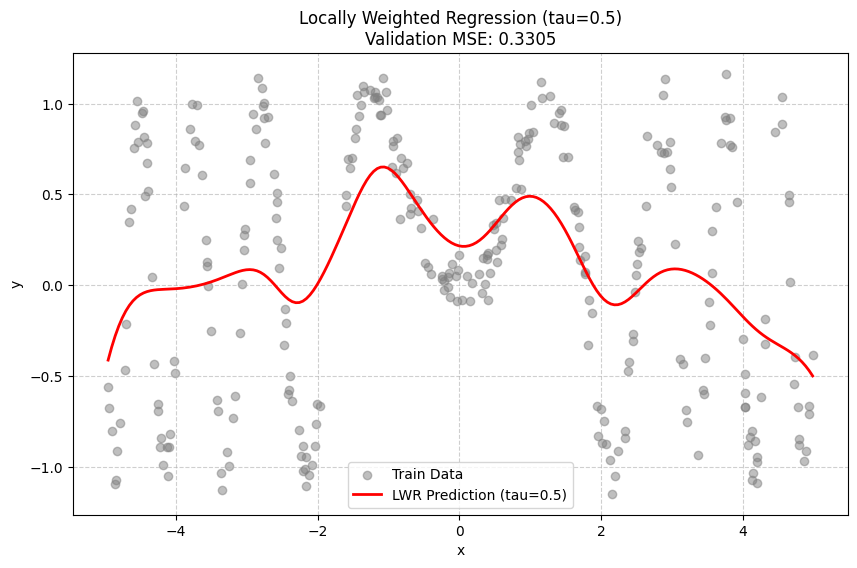

In [13]:
# train 데이터와 예측 결과를 함께 시각화
#  촘촘하게 x값들을 생성. (200개)
x_plot = np.linspace(x_train.min(), x_train.max(), 200)
y_plot = np.array([lwr_predict(x_q, x_train, y_train, tau) for x_q in x_plot])

plt.figure(figsize=(10, 6))
# train 데이터 시각화
plt.scatter(x_train, y_train, color='gray', alpha=0.5, label='Train Data')
# 예측 결과 시각화
plt.plot(x_plot, y_plot, color='red', linewidth=2, label=f'LWR Prediction (tau={tau})')

plt.title(f'Locally Weighted Regression (tau={tau})\nValidation MSE: {mse:.4f}')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()